# 📚 Notebook 2: Content-Based Filtering

Two text representations are built and compared:
1. **TF-IDF** vectorisation + Cosine Similarity
2. **Bag-of-Words (BoW)** vectorisation + Cosine Similarity

For each representation we build a content-based recommender and compute evaluation metrics.

In [1]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────
DATA_DIR    = Path('data/raw')
FIGURES_DIR = Path('figures/content_based')
MODELS_DIR  = Path('models/content_based')
RESULTS_DIR = Path('results')

for _dir in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


## 1. Load & Prepare Data

In [2]:
ratings = pd.read_csv('data/raw/ratings.csv')
courses = pd.read_csv('data/raw/course_genre.csv')

genre_cols = courses.columns[2:].tolist()

# Build a rich text document per course: title + genre tags repeated
def build_course_text(row):
    title = str(row['TITLE'])
    tags  = ' '.join([col for col in genre_cols if row[col] == 1])
    return (title + ' ' + tags).strip().lower()

courses['doc'] = courses.apply(build_course_text, axis=1)
print(courses[['COURSE_ID', 'doc']].head(5).to_string())


    COURSE_ID                                                                                        doc
0    ML0201EN  robots are coming  build iot apps with watson  swift  and node red backenddev frontenddev
1    ML0122EN                     accelerating deep learning with gpu python machinelearning datascience
2  GPXX0ZG0EN         consuming restful services using the reactive jax rs client backenddev frontenddev
3    RP0105EN                 analyzing big data in r using apache spark database dataanalysis bigdata r
4  GPXX0Z2PEN     containerizing  packaging  and running a spring boot application containers backenddev


## 2. TF-IDF Vectorisation

In [3]:
tfidf_vec = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1,2))
tfidf_matrix = tfidf_vec.fit_transform(courses['doc'])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Vocabulary size     : {len(tfidf_vec.vocabulary_)}")


TF-IDF matrix shape : (307, 500)
Vocabulary size     : 500


In [4]:
# TF-IDF cosine similarity
tfidf_cos = cosine_similarity(tfidf_matrix)
tfidf_cos_df = pd.DataFrame(tfidf_cos, index=courses['COURSE_ID'], columns=courses['COURSE_ID'])
print("TF-IDF cosine similarity matrix (5x5 sample):")
tfidf_cos_df.iloc[:5, :5].round(4)


TF-IDF cosine similarity matrix (5x5 sample):


COURSE_ID,ML0201EN,ML0122EN,GPXX0ZG0EN,RP0105EN,GPXX0Z2PEN
COURSE_ID,,,,,
ML0201EN,1.0000,0.0,0.0969,0.0000,0.0269
ML0122EN,0.0000,1.0,0.0000,0.0000,0.0000
GPXX0ZG0EN,0.0969,0.0,1.0000,0.0251,0.0265
RP0105EN,0.0000,0.0,0.0251,1.0000,0.0000
GPXX0Z2PEN,0.0269,0.0,0.0265,0.0000,1.0000


## 3. Bag-of-Words Vectorisation

In [5]:
bow_vec = CountVectorizer(stop_words='english', max_features=500, ngram_range=(1,2))
bow_matrix = bow_vec.fit_transform(courses['doc'])

print(f"BoW matrix shape    : {bow_matrix.shape}")
print(f"Vocabulary size     : {len(bow_vec.vocabulary_)}")


BoW matrix shape    : (307, 500)
Vocabulary size     : 500


In [6]:
bow_cos = cosine_similarity(bow_matrix)
bow_cos_df = pd.DataFrame(bow_cos, index=courses['COURSE_ID'], columns=courses['COURSE_ID'])
print("BoW cosine similarity matrix (5x5 sample):")
bow_cos_df.iloc[:5, :5].round(4)


BoW cosine similarity matrix (5x5 sample):


COURSE_ID,ML0201EN,ML0122EN,GPXX0ZG0EN,RP0105EN,GPXX0Z2PEN
COURSE_ID,,,,,
ML0201EN,1.0000,0.0,0.2004,0.0000,0.1091
ML0122EN,0.0000,1.0,0.0000,0.0000,0.0000
GPXX0ZG0EN,0.2004,0.0,1.0000,0.0625,0.1021
RP0105EN,0.0000,0.0,0.0625,1.0000,0.0000
GPXX0Z2PEN,0.1091,0.0,0.1021,0.0000,1.0000


## 4. Recommendation Function

In [7]:
def get_content_recommendations(course_id, sim_df, top_n=10, exclude_self=True):
    """Return top_n most similar courses to course_id."""
    if course_id not in sim_df.index:
        return pd.Series(dtype=float)
    scores = sim_df[course_id].copy()
    if exclude_self:
        scores = scores.drop(index=course_id, errors='ignore')
    return scores.sort_values(ascending=False).head(top_n)

# Demo
sample_course = courses['COURSE_ID'].iloc[0]
print(f"Course: {sample_course}  —  {courses.loc[courses['COURSE_ID']==sample_course,'TITLE'].values[0]}")

print("\n── TF-IDF Top-10 ──")
rec_tfidf = get_content_recommendations(sample_course, tfidf_cos_df)
for cid, score in rec_tfidf.items():
    title = courses.loc[courses['COURSE_ID']==cid, 'TITLE'].values
    print(f"  {cid:20s} {score:.4f}  {title[0] if len(title) else ''}")

print("\n── BoW Top-10 ──")
rec_bow = get_content_recommendations(sample_course, bow_cos_df)
for cid, score in rec_bow.items():
    title = courses.loc[courses['COURSE_ID']==cid, 'TITLE'].values
    print(f"  {cid:20s} {score:.4f}  {title[0] if len(title) else ''}")


Course: ML0201EN  —  robots are coming  build iot apps with watson  swift  and node red

── TF-IDF Top-10 ──
  CB0105ENv1           0.4801  node red  basics to bots
  SW0101EN             0.3852  build swift mobile apps with watson ai services
  BC0202EN             0.2919  build an iot blockchain network for a supply chain
  GPXX06KEEN           0.2588  build a smart search form with algolia
  SW0201EN             0.2401  how to build watson ai and swift apis and make money
  IT0101EN             0.2210  building robots with tjbot
  excourse88           0.2104  javascript basics
  GPXX0KV4EN           0.1886  getting started with node js
  CB0201EN             0.1864  build chatbots with watson assistant
  excourse93           0.1681  interactivity with javascript and jquery

── BoW Top-10 ──
  CB0105ENv1           0.4781  node red  basics to bots
  SW0101EN             0.4140  build swift mobile apps with watson ai services
  GPXX06KEEN           0.3780  build a smart search form wit

## 5. Profile-based Recommendations (User History)

In [8]:
def user_content_recs(user_id, ratings_df, sim_df, top_n=10):
    """
    Build a user profile as the average similarity vector of
    previously rated courses, then recommend unseen courses.
    """
    seen = ratings_df[ratings_df['user'] == user_id]['item'].tolist()
    seen = [c for c in seen if c in sim_df.index]
    if not seen:
        return pd.Series(dtype=float)

    # Average similarity vector
    profile = sim_df.loc[seen].mean(axis=0)
    profile = profile.drop(index=seen, errors='ignore')
    return profile.sort_values(ascending=False).head(top_n)

# Pick a user with enough history
active_users = ratings.groupby('user').filter(lambda x: len(x) >= 5)
sample_user  = active_users['user'].iloc[0]
print(f"Sample user: {sample_user}")
print("\nTF-IDF recs:")
print(user_content_recs(sample_user, ratings, tfidf_cos_df))
print("\nBoW recs:")
print(user_content_recs(sample_user, ratings, bow_cos_df))


Sample user: 1889878

TF-IDF recs:
COURSE_ID
excourse22    0.116385
excourse62    0.114010
ML0101EN      0.102918
excourse38    0.098848
excourse21    0.088049
excourse60    0.087676
TMP107        0.087125
DS0321EN      0.086631
excourse49    0.086009
excourse23    0.083953
dtype: float64

BoW recs:
COURSE_ID
excourse22    0.159829
excourse62    0.149380
excourse65    0.131916
excourse38    0.131910
ML0101EN      0.127823
TMP107        0.126984
excourse69    0.126917
DS0110EN      0.124508
DJ0101EN      0.123034
excourse09    0.122896
dtype: float64


## 6. Evaluation Metrics

In [9]:
def evaluate_content_model(sim_df, ratings_df, courses_df, top_n=10,
                            n_users=200, seed=42):
    """
    Evaluate a content-based model using held-out ratings.
    Splits each user's ratings 80/20 and checks top_n recs.
    Returns a dict of metrics.
    """
    rng = np.random.default_rng(seed)
    users = ratings_df['user'].value_counts()
    users = users[users >= 5].index.tolist()
    users = rng.choice(users, min(n_users, len(users)), replace=False)

    all_courses  = set(sim_df.index)
    hit, prec_list, rec_list, ndcg_list, rmse_list = [], [], [], [], []
    recommended_set = set()

    for u in users:
        u_ratings = ratings_df[ratings_df['user'] == u].set_index('item')['rating']
        items = u_ratings.index.tolist()
        if len(items) < 4:
            continue
        # 80/20 split
        n_train = max(1, int(len(items) * 0.8))
        train_items = items[:n_train]
        test_items  = set(items[n_train:])

        recs = user_content_recs(u, ratings_df[ratings_df['item'].isin(train_items)],
                                  sim_df, top_n=top_n)
        if recs.empty:
            continue
        rec_ids = set(recs.index)
        recommended_set.update(rec_ids)

        # Hits
        hits = rec_ids & test_items
        hit.append(1 if hits else 0)
        prec_list.append(len(hits) / top_n)
        rec_list.append(len(hits) / len(test_items) if test_items else 0)

        # NDCG
        dcg, ideal = 0.0, 0.0
        for rank, item in enumerate(recs.index, 1):
            rel = 1 if item in test_items else 0
            dcg += rel / np.log2(rank + 1)
        for rank in range(1, min(len(test_items), top_n) + 1):
            ideal += 1 / np.log2(rank + 1)
        ndcg_list.append(dcg / ideal if ideal > 0 else 0)

        # RMSE / MAE on overlapping items
        for item in rec_ids & set(u_ratings.index):
            pred = float(recs.loc[item]) * 3   # scale similarity → rating range
            actual = u_ratings[item]
            rmse_list.append((pred - actual) ** 2)

    # Diversity (avg pairwise distance between recommended courses)
    all_recs = list(recommended_set & set(sim_df.index))
    if len(all_recs) > 1:
        sub = sim_df.loc[all_recs, all_recs].values
        np.fill_diagonal(sub, 0)
        diversity = 1 - sub.sum() / (len(all_recs) * (len(all_recs) - 1))
    else:
        diversity = 0

    # Novelty: avg -log2(popularity) of recommended items
    pop = ratings_df['item'].value_counts(normalize=True)
    novelty = np.mean([-np.log2(pop.get(c, 1e-9)) for c in recommended_set])

    # Coverage
    coverage = len(recommended_set) / len(all_courses) if all_courses else 0

    # Serendipity (proxy): proportion of recs that are in niche genres only)
    niche = courses_df[courses_df['num_genres'] >= 3]['COURSE_ID'] if 'num_genres' in courses_df.columns else pd.Series()
    serendipity = len(recommended_set & set(niche)) / len(recommended_set) if recommended_set else 0

    return {
        'HitRate@10'   : np.mean(hit),
        'Precision@10' : np.mean(prec_list),
        'Recall@10'    : np.mean(rec_list),
        'NDCG@10'      : np.mean(ndcg_list),
        'RMSE'         : np.sqrt(np.mean(rmse_list)) if rmse_list else np.nan,
        'MAE'          : np.sqrt(np.mean(np.abs(rmse_list))) if rmse_list else np.nan,
        'Diversity'    : diversity,
        'Novelty'      : novelty,
        'Coverage'     : coverage,
        'Serendipity'  : serendipity,
    }


In [10]:
# Add num_genres for serendipity computation
genre_cols = courses.columns[2:-1].tolist()   # exclude 'doc'
courses['num_genres'] = courses[genre_cols].sum(axis=1)

print("Evaluating TF-IDF content-based model ...")
eval_tfidf = evaluate_content_model(tfidf_cos_df, ratings, courses, n_users=300)

print("Evaluating BoW content-based model ...")
eval_bow   = evaluate_content_model(bow_cos_df, ratings, courses, n_users=300)

results_cb = pd.DataFrame([eval_tfidf, eval_bow], index=['TF-IDF', 'BoW']).round(4)
print("\n=== Content-Based Evaluation Results ===")
print(results_cb.to_string())


Evaluating TF-IDF content-based model ...
Evaluating BoW content-based model ...

=== Content-Based Evaluation Results ===
        HitRate@10  Precision@10  Recall@10  NDCG@10    RMSE     MAE  Diversity  Novelty  Coverage  Serendipity
TF-IDF      0.4533        0.0540     0.2766   0.1647  2.2906  2.2906     0.9498  17.9596    0.4919       0.1192
BoW         0.4100        0.0497     0.2540   0.1570  2.0346  2.0346     0.9169  19.0289    0.5244       0.1180


## 7. Visualise Results

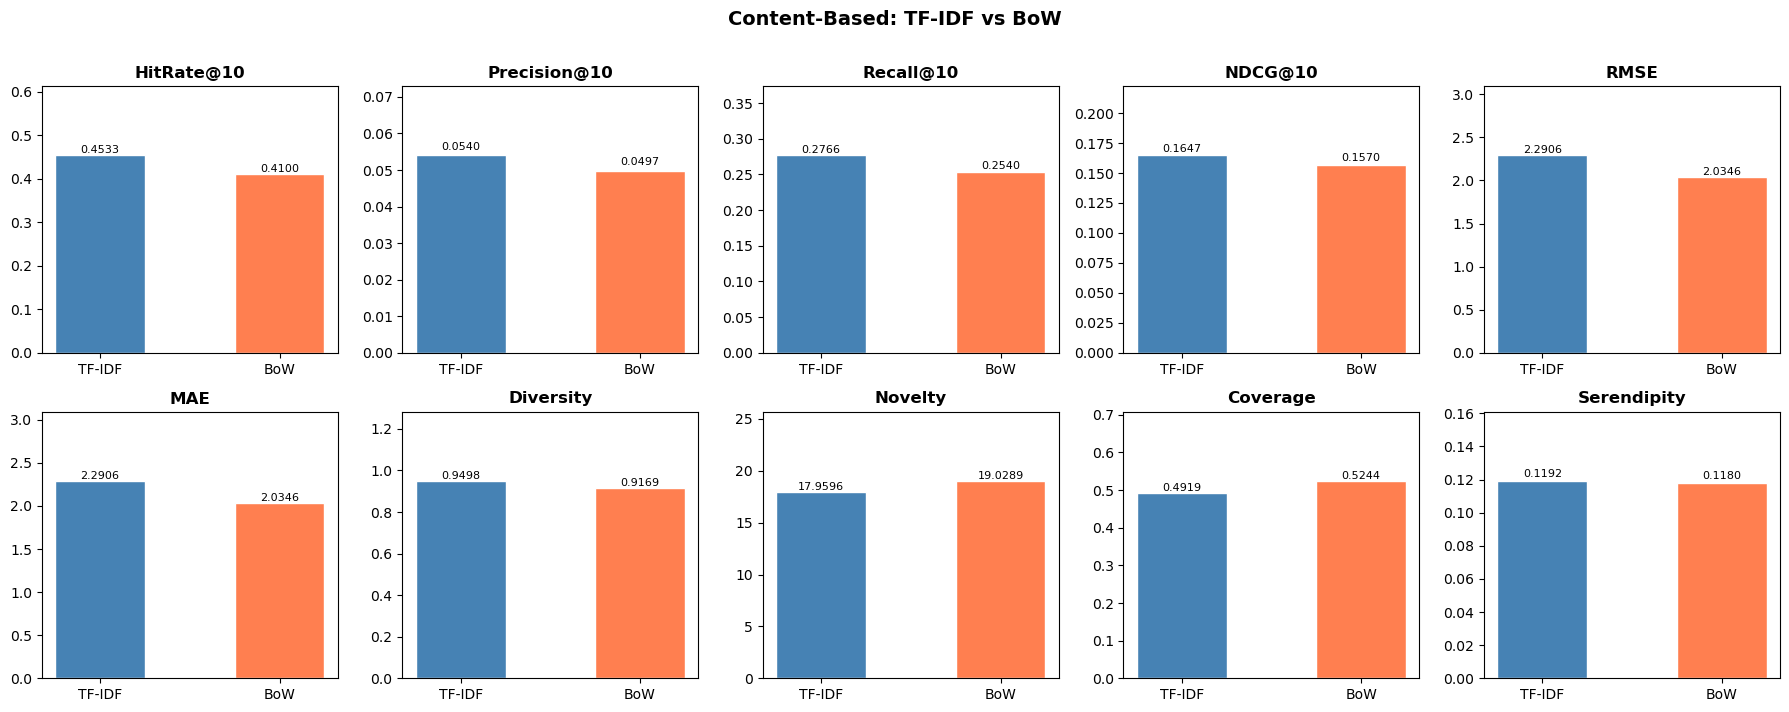

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
metrics = list(results_cb.columns)
colors  = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(results_cb.index, results_cb[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, results_cb[metric].max() * 1.35 + 1e-6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Content-Based: TF-IDF vs BoW', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_tfidf_vs_bow_metrics.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Similarity Score Distribution

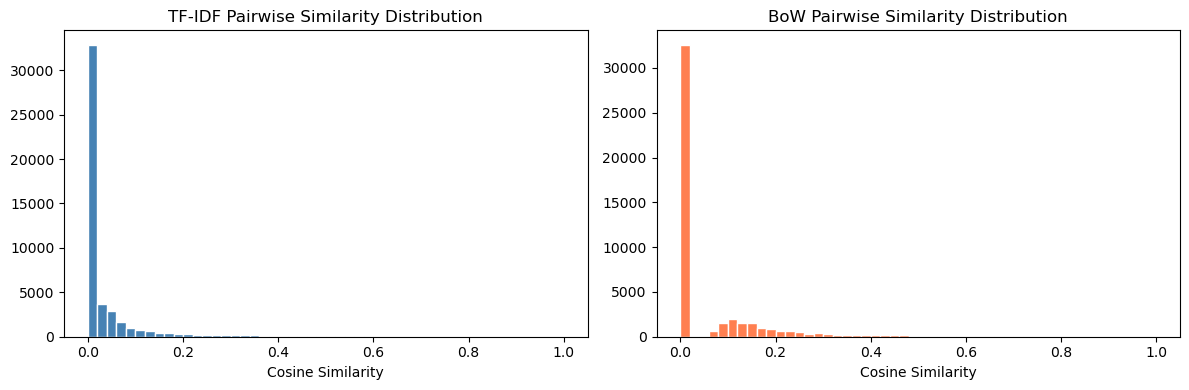

TF-IDF mean sim: 0.0349  std: 0.0877
BoW    mean sim: 0.0646  std: 0.1255


In [12]:
tfidf_sims = tfidf_cos[np.triu_indices_from(tfidf_cos, k=1)]
bow_sims   = bow_cos[np.triu_indices_from(bow_cos, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tfidf_sims, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity Distribution')
axes[0].set_xlabel('Cosine Similarity')

axes[1].hist(bow_sims, bins=50, color='coral', edgecolor='white')
axes[1].set_title('BoW Pairwise Similarity Distribution')
axes[1].set_xlabel('Cosine Similarity')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_similarity_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"TF-IDF mean sim: {tfidf_sims.mean():.4f}  std: {tfidf_sims.std():.4f}")
print(f"BoW    mean sim: {bow_sims.mean():.4f}  std: {bow_sims.std():.4f}")


## 9. Save Artefacts for Notebook 4

In [13]:
import pickle

# Similarity matrices
with open(MODELS_DIR / 'tfidf_cos_df.pkl', 'wb') as f: pickle.dump(tfidf_cos_df, f)
with open(MODELS_DIR / 'bow_cos_df.pkl',   'wb') as f: pickle.dump(bow_cos_df,   f)

# Vectorisers (reusable for new course docs)
with open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'wb') as f: pickle.dump(tfidf_vec, f)
with open(MODELS_DIR / 'bow_vectorizer.pkl',   'wb') as f: pickle.dump(bow_vec,   f)

# Evaluation results
results_cb.to_csv(RESULTS_DIR / 'results_content_based.csv')

print("Saved models  →", MODELS_DIR)
print("  tfidf_cos_df.pkl")
print("  bow_cos_df.pkl")
print("  tfidf_vectorizer.pkl")
print("  bow_vectorizer.pkl")
print("Saved results →", RESULTS_DIR / 'results_content_based.csv')


Saved models  → models\content_based
  tfidf_cos_df.pkl
  bow_cos_df.pkl
  tfidf_vectorizer.pkl
  bow_vectorizer.pkl
Saved results → results\results_content_based.csv
